In [1]:
import h5ify
import numpy as np
import matplotlib.pyplot as plt

from util import plot_corner, plot_multiple

from bilby.core.result import read_in_result

%load_ext autoreload
%autoreload 2

In [3]:
datadir = '../../data/inference/strong'

In [5]:
noah_model_stegmann_code_noah_data = read_in_result(
    f'{datadir}/Gaussian_Isotropic_Cut-Noah-model_Stegmann-code_Noah-data/run_result.hdf5'
)
noah_model_stegmann_code_noah_data = noah_model_stegmann_code_noah_data.posterior.to_dict(orient='list')
noah_model_stegmann_code_noah_data = {k : np.array(v) for k, v in noah_model_stegmann_code_noah_data.items()}

In [6]:
stegmann_model_stegmann_data = read_in_result(f'{datadir}/out_Gaussian_Isotropic_Cut/Gaussian_Isotropic_Cut_result.hdf5')
stegmann_model_stegmann_data = stegmann_model_stegmann_data.posterior.to_dict(orient='list')
stegmann_model_stegmann_data = {k : np.array(v) for k, v in stegmann_model_stegmann_data.items()}

In [7]:
noah_model_stegmann_data = read_in_result(f'{datadir}/out_Gaussian_Isotropic_Cut-NOAH-LOG-MODEL/Gaussian_Isotropic_Cut-NOAH-LOG-MODEL_result.hdf5')
noah_model_stegmann_data = noah_model_stegmann_data.posterior.to_dict(orient='list')
noah_model_stegmann_data = {k : np.array(v) for k, v in noah_model_stegmann_data.items()}

In [8]:
noah_model_noah_data = h5ify.load('/home/noah.wolfe/projects/tilts-and-kicks/data/inference/strong/spl-novar-nlive150-stegmann-data/posterior.h5')

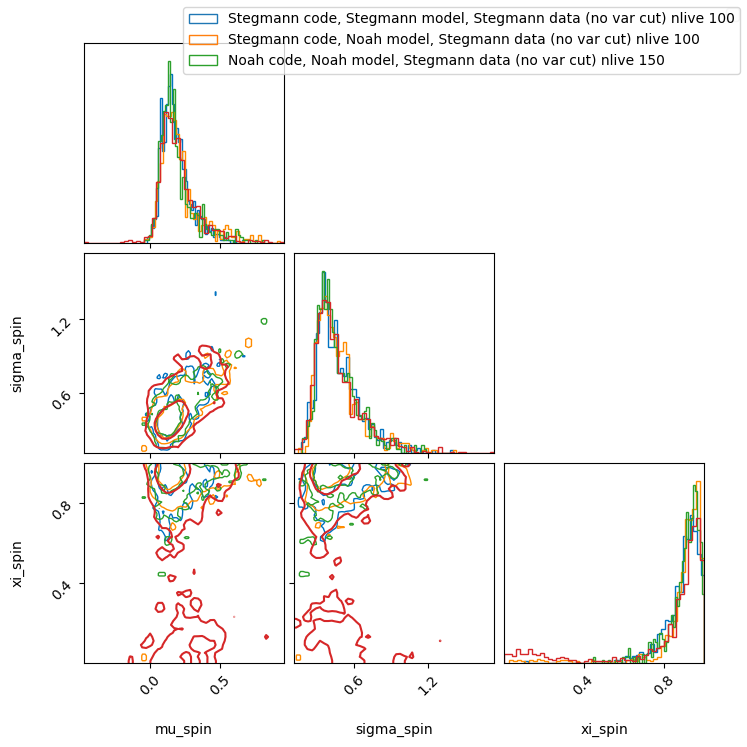

In [10]:
fig = plot_multiple(
    [
        stegmann_model_stegmann_data,
        noah_model_stegmann_data,
        noah_model_stegmann_code_noah_data
    ],
    labels=dict(
        mu_tilt_1=r'$\mu_\tau$',
        sigma_tilt_1=r'$\sigma_\tau$',
        weight_a=r'$\xi_\tau$'
    ),
    plot_datapoints=False,
    fill_contours=False,
    no_fill_contours=True,
    levels=(0.5, 0.9)
)

fig = plot_corner(
    noah_model_noah_data['samples'],
    labels=['mu_spin', 'sigma_spin', 'xi_spin'],
    plot_datapoints=False,
    fill_contours=False,
    no_fill_contours=True,
    levels=(0.5, 0.9),
    fig=fig,
    color='C3'
)

from matplotlib.patches import Patch

fig.legend(
    handles=[
        Patch(edgecolor='C0', facecolor='none'),
        Patch(edgecolor='C1', facecolor='none'),
        Patch(edgecolor='C2', facecolor='none'), 
    ],
    labels=[
        'Stegmann code, Stegmann model, Stegmann data (no var cut) nlive 100',
        'Stegmann code, Noah model, Stegmann data (no var cut) nlive 100',
        'Noah code, Noah model, Stegmann data (no var cut) nlive 150'
    ]
)

In [20]:
stegmann_model_stegmann_data.keys()

dict_keys(['alpha', 'beta', 'gaussian_mass_maximum', 'lam', 'lamb', 'log_likelihood', 'log_prior', 'm_cut', 'mmax', 'mmin', 'mpp', 'mu_1', 'mu_2', 'mu_3', 'mu_tilt_1', 'sigma_1', 'sigma_2', 'sigma_3', 'sigma_tilt_1', 'sigpp', 'weight_a'])

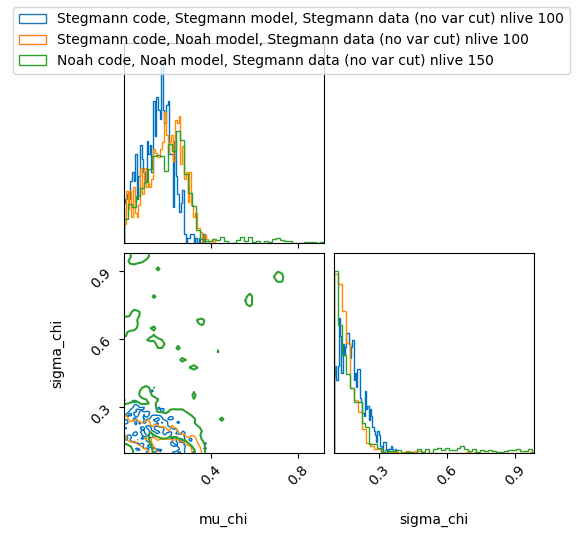

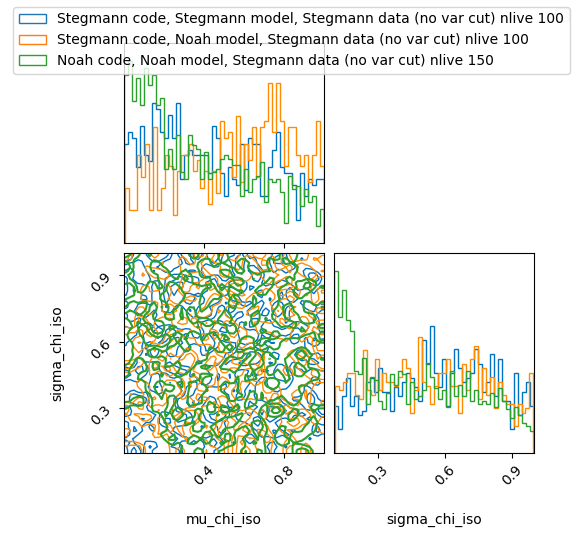

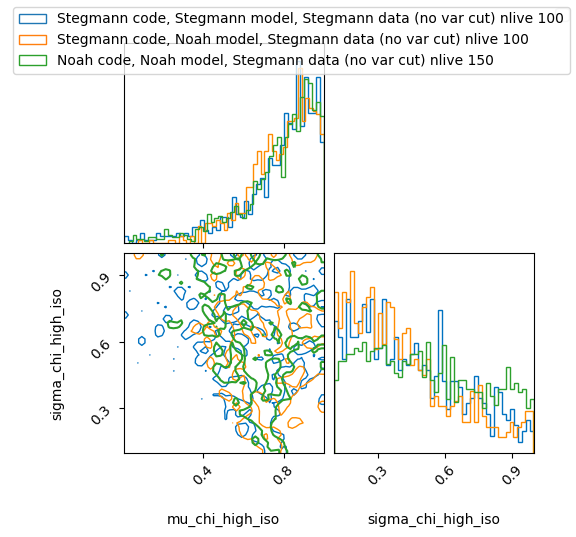

In [21]:
for i in [1, 2, 3]:

    labels = [f'mu_{i}', f'sigma_{i}']
    if i == 1:
        latex_labels = [r'$\mu_\chi', r'$\sigma_\chi$']
    elif i == 2:
        latex_labels = [r'$\mu_\chi^\mathrm{iso}', r'$\sigma_\chi^\mathrm{iso}$'] 
    elif i == 3:
        latex_labels = [r'$\mu_\chi^\mathrm{high\,iso}', r'$\sigma_\chi^\mathrm{high\,iso}$']

    fig = plot_multiple(
        [
            stegmann_model_stegmann_data,
            noah_model_stegmann_data,
        ],
        labels={k : v for k, v in zip(labels, latex_labels)},
        plot_datapoints=False,
        fill_contours=False,
        no_fill_contours=True,
        levels=(0.5, 0.9)
    )

    if i == 1:
        labels = ['mu_chi', 'sigma_chi']
    elif i == 2:
        labels = ['mu_chi_iso', 'sigma_chi_iso']
    elif i == 3:
        labels = ['mu_chi_high_iso', 'sigma_chi_high_iso']

    fig = plot_corner(
        noah_model_noah_data['samples'],
        labels=labels,
        plot_datapoints=False,
        fill_contours=False,
        no_fill_contours=True,
        levels=(0.5, 0.9),
        fig=fig,
        color='C2'
    )

    from matplotlib.patches import Patch

    fig.legend(
        handles=[
            Patch(edgecolor='C0', facecolor='none'),
            Patch(edgecolor='C1', facecolor='none'),
            Patch(edgecolor='C2', facecolor='none'), 
        ],
        labels=[
            'Stegmann code, Stegmann model, Stegmann data (no var cut) nlive 100',
            'Stegmann code, Noah model, Stegmann data (no var cut) nlive 100',
            'Noah code, Noah model, Stegmann data (no var cut) nlive 150'
        ]
    )